### 1. Generate Synthetic Data

Let's create some simple linear data with a bit of noise to simulate a real-world scenario.

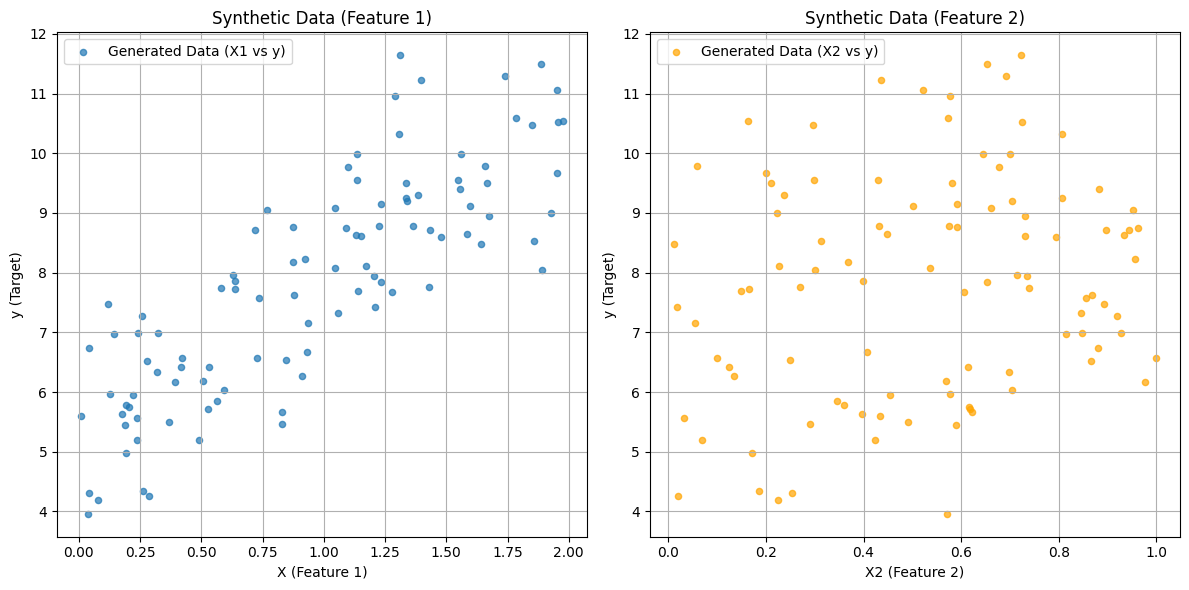

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Generate synthetic data with two features
np.random.seed(0) # for reproducibility
X = 2 * np.random.rand(100, 1) # First feature
X2 = 1 * np.random.rand(100, 1) # Second feature

# Combine features into a single array
X_multi = np.hstack((X, X2))

# y = 4 + 3*X1 + 2*X2 + noise
y = 4 + 3 * X + 2 * X2 + np.random.randn(100, 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Plot the generated data (for X1 vs y, and X2 vs y separately)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X, y, s=20, alpha=0.7, label='Generated Data (X1 vs y)')
plt.xlabel('X (Feature 1)')
plt.ylabel('y (Target)')
plt.title('Synthetic Data (Feature 1)')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X2, y, s=20, alpha=0.7, label='Generated Data (X2 vs y)', color='orange')
plt.xlabel('X2 (Feature 2)')
plt.ylabel('y (Target)')
plt.title('Synthetic Data (Feature 2)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### 2. Train a Linear Regression Model

Now, we'll use `scikit-learn` to train a simple Linear Regression model on our training data.

In [85]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training sets
model.fit(X_train, y_train)

print(f"Model Coefficients: {model.coef_[0]}")
print(f"Model Intercept: {model.intercept_[0]:.2f}")

Model Coefficients: [2.70071288 1.86236882]
Model Intercept: 4.21


### 3. Make Predictions and Evaluate the Model

After training, we can use the model to make predictions on the test set and evaluate its performance.

In [86]:
# Make predictions using the testing set
y_pred = model.predict(X_test)

# The mean squared error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared (Coefficient of Determination): {r2:.2f}")

Mean Squared Error: 0.73
R-squared (Coefficient of Determination): 0.68


### 4. Visualize the Model's Predictions

Let's plot the original data along with the regression line learned by our model.

ValueError: x and y must be the same size

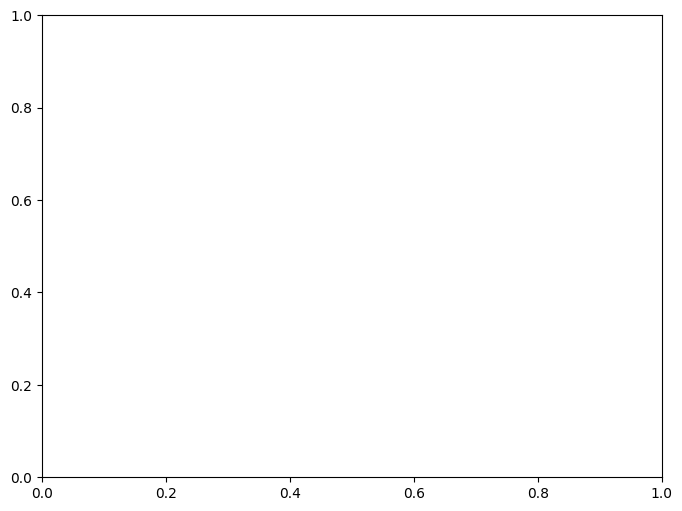

In [87]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, s=30, alpha=0.8, label='Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression Prediction')

# Plot the true underlying relationship (for comparison, if known)
X_true = np.array([[0], [2]])
y_true = 4 + 3 * X_true
plt.plot(X_true, y_true, 'g--', label='True Relationship (y = 4 + 3x)')

plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Linear Regression Model Predictions vs. True Data')
plt.grid(True)
plt.legend()
plt.show()

### 5. Add Polynomial Features and Retrain the Model

We will use `PolynomialFeatures` to create higher-order terms from our existing feature. This allows our linear model to fit a curved line.

In [88]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features (e.g., degree 5 for x, x^2, x^3, x^4, x^5)
degree = 5
poly_features = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Split the new polynomial data into training and testing sets
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Create a new Linear Regression model for polynomial features
model_poly = LinearRegression()

# Train the new model
model_poly.fit(X_train_poly, y_train)

print(f"Polynomial Model Coefficients: {model_poly.coef_[0]}")
print(f"Polynomial Model Intercept: {model_poly.intercept_[0]:.2f}")

Polynomial Model Coefficients: [  5.57692988 -13.03643942  19.49094463 -11.30428333   2.21678077]
Polynomial Model Intercept: 5.06


### 6. Evaluate the Polynomial Model

Now, let's evaluate the performance of our model with polynomial features.

In [89]:
# Make predictions using the testing set with polynomial features
y_pred_poly = model_poly.predict(X_test_poly)

# Evaluate the new model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Mean Squared Error: {mse_poly:.2f}")
print(f"Polynomial R-squared (Coefficient of Determination): {r2_poly:.2f}")

Polynomial Mean Squared Error: 0.75
Polynomial R-squared (Coefficient of Determination): 0.67


### 7. Visualize the Polynomial Model's Predictions

Let's visualize how the polynomial model fits the data.

In [90]:
prompt = "The quick brown fox jumps over the"

print("\n--- Generating with max_new_tokens=10 ---")
result_10 = generator(prompt, max_new_tokens=10, num_return_sequences=1)
print(result_10[0]['generated_text'])

print("\n--- Generating with max_new_tokens=30 ---")
result_30 = generator(prompt, max_new_tokens=30, num_return_sequences=1)
print(result_30[0]['generated_text'])

print("\n--- Generating with max_new_tokens=50 ---")
result_50 = generator(prompt, max_new_tokens=50, num_return_sequences=1)
print(result_50[0]['generated_text'])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Generating with max_new_tokens=10 ---


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The quick brown fox jumps over the ground and pulls the trigger, and a loud,

--- Generating with max_new_tokens=30 ---


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The quick brown fox jumps over the fence. This time his legs get in the way. The fox jumps down. The fox looks up and sees that he's getting in trouble. He

--- Generating with max_new_tokens=50 ---
The quick brown fox jumps over the fence to get a better look at the house.

"I was just looking up when I saw it, but I wasn't sure what I saw," he says.

But when he saw the house two hours later, he realized the


In [91]:
result = generator("Hello, I'm a language model, and I", max_new_tokens=50, num_return_sequences=1)
print(result[0]['generated_text'])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Hello, I'm a language model, and I have two languages: English and Spanish. I'm not fluent in any of them.

The language model is basically what I do when I create a new program. It's an object-oriented programming language, so you can do things like writing


In [92]:
from transformers import pipeline

# Create a text generation pipeline using the 'gpt2' model
generator = pipeline('text-generation', model='gpt2')

print("Text generation pipeline created successfully!")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text generation pipeline created successfully!


To use the generator, you can call it with a prompt string:

```python
result = generator("Hello, I'm a language model,", max_new_tokens=50)
print(result[0]['generated_text'])
```

In [93]:
from transformers import pipeline

In [ ]:
!pip install transformers

After installation, you can import and use the library. For example, to import a pipeline:
```python
from transformers import pipeline
```

In [94]:
print(f"Model Coefficients (Feature 1, Feature 2): {model.coef_[0]}")
print(f"Model Intercept: {model.intercept_[0]:.2f}")

Model Coefficients (Feature 1, Feature 2): [2.70071288 1.86236882]
Model Intercept: 4.21


In [95]:
print(f"Model Coefficients (Feature 1, Feature 2): {model.coef_[0]}")
print(f"Model Intercept: {model.intercept_[0]:.2f}")

Model Coefficients (Feature 1, Feature 2): [2.70071288 1.86236882]
Model Intercept: 4.21


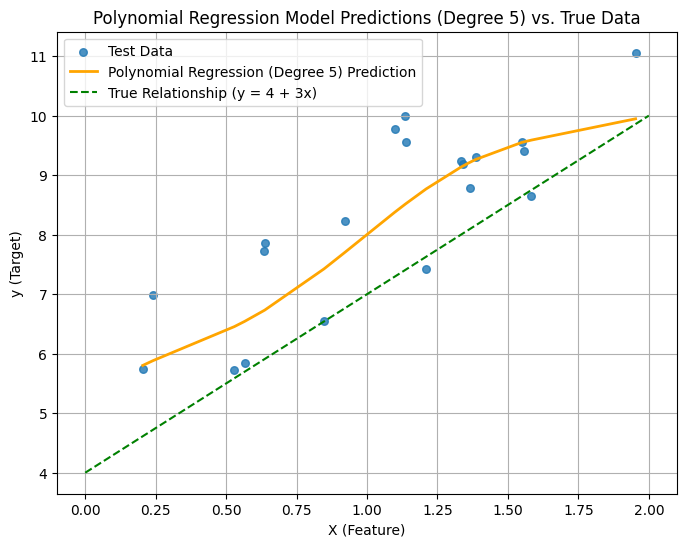

In [96]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
# Plot the first feature of X_test against y_test
plt.scatter(X_test[:, 0], y_test, s=30, alpha=0.8, label='Test Data')

# To plot the polynomial curve, we need to sort the X values
# Use only the first feature for plotting the polynomial curve
X_sorted_plot = np.sort(X_test[:, 0]).reshape(-1, 1) # Sort and reshape to (n_samples, 1)
X_sorted_poly = poly_features.transform(X_sorted_plot)
y_pred_sorted_poly = model_poly.predict(X_sorted_poly)

plt.plot(X_sorted_plot, y_pred_sorted_poly, color='orange', linewidth=2, label=f'Polynomial Regression (Degree {degree}) Prediction')

# Plot the true underlying relationship (for comparison)
X_true_plot = np.linspace(0, 2, 100).reshape(-1, 1)
y_true_plot = 4 + 3 * X_true_plot
plt.plot(X_true_plot, y_true_plot, 'g--', label='True Relationship (y = 4 + 3x)')

plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title(f'Polynomial Regression Model Predictions (Degree {degree}) vs. True Data')
plt.grid(True)
plt.legend()
plt.show()

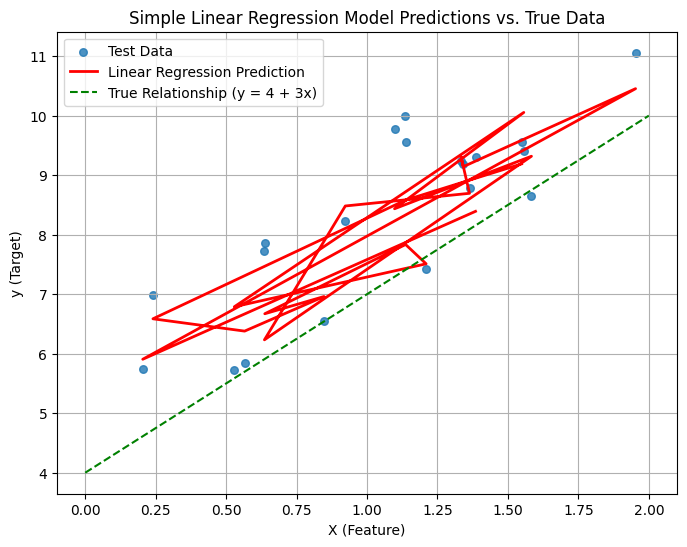

In [97]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
# Plot the first feature of X_test against y_test
plt.scatter(X_test[:, 0], y_test, s=30, alpha=0.8, label='Test Data')
plt.plot(X_test[:, 0], y_pred, color='red', linewidth=2, label='Linear Regression Prediction')

# Plot the true underlying relationship (for comparison, if known)
X_true = np.array([[0], [2]])
y_true = 4 + 3 * X_true
plt.plot(X_true, y_true, 'g--', label='True Relationship (y = 4 + 3x)')

plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Simple Linear Regression Model Predictions vs. True Data')
plt.grid(True)
plt.legend()
plt.show()

### 9. Analyze Residuals of the Polynomial Model

Let's examine the residuals for our polynomial model to check its assumptions and fit.

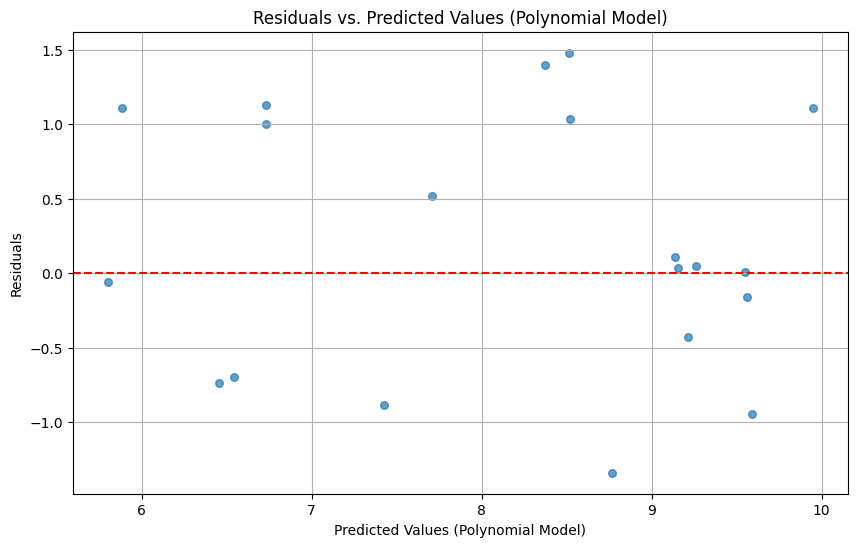

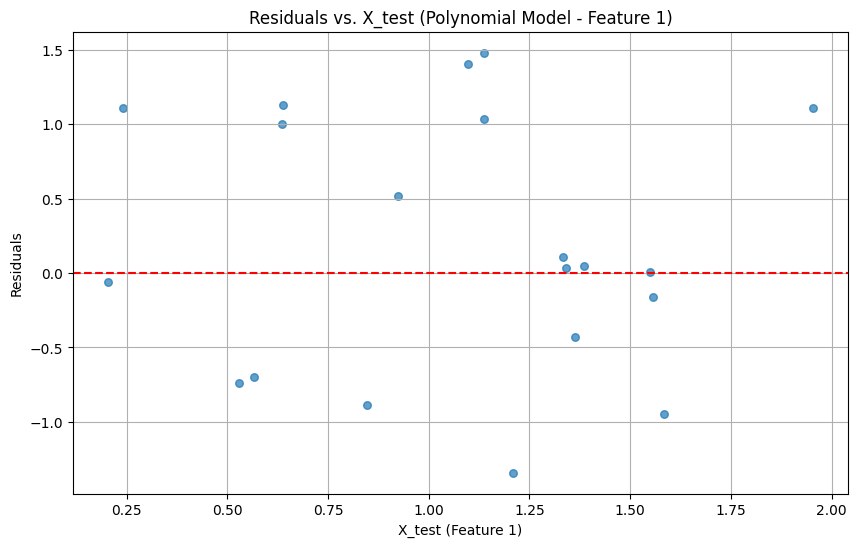

In [98]:
# Calculate residuals for the polynomial model
residuals_poly = y_test - y_pred_poly

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_poly, residuals_poly, s=30, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel('Predicted Values (Polynomial Model)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values (Polynomial Model)')
plt.grid(True)
plt.show()

# Also plot residuals against the independent variable X_test
# Note: We use X_test here, not X_test_poly, to see the pattern against the original feature
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], residuals_poly, s=30, alpha=0.7) # Plotting against the first feature of X_test
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('X_test (Feature 1)')
plt.ylabel('Residuals')
plt.title('Residuals vs. X_test (Polynomial Model - Feature 1)')
plt.grid(True)
plt.show()

### 8. Analyze Residuals of the Simple Linear Model

Residual analysis helps us check the assumptions of linear regression. We'll plot the residuals against the predicted values.

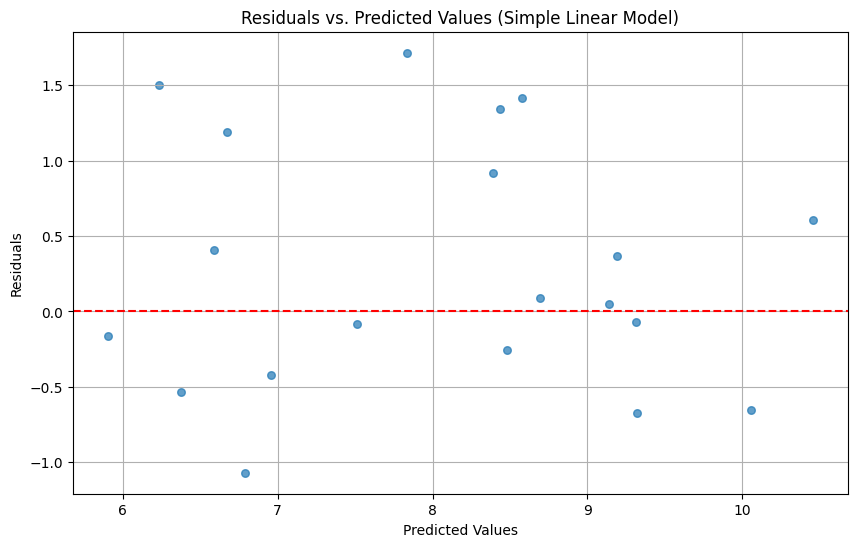

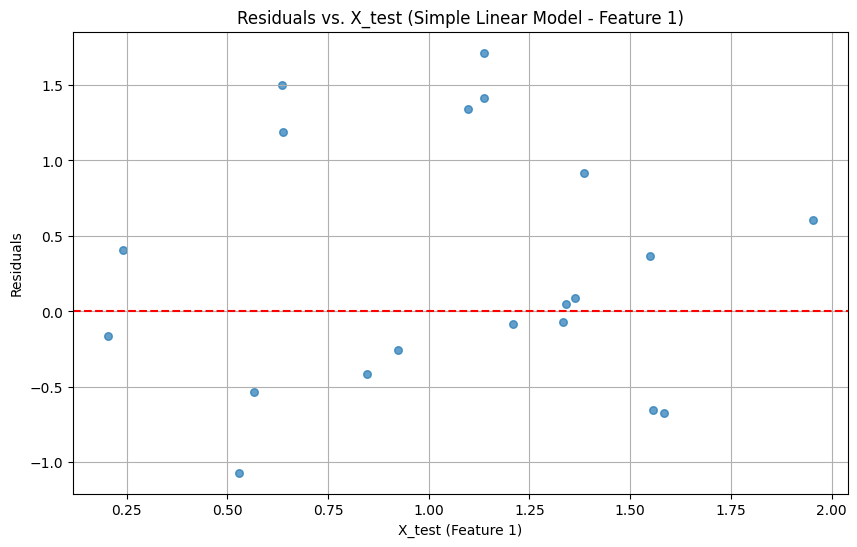

In [99]:
# Calculate residuals for the simple linear model
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, s=30, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values (Simple Linear Model)')
plt.grid(True)
plt.show()

# Also plot residuals against the independent variable X_test
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], residuals, s=30, alpha=0.7) # Plotting against the first feature of X_test
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('X_test (Feature 1)')
plt.ylabel('Residuals')
plt.title('Residuals vs. X_test (Simple Linear Model - Feature 1)')
plt.grid(True)
plt.show()

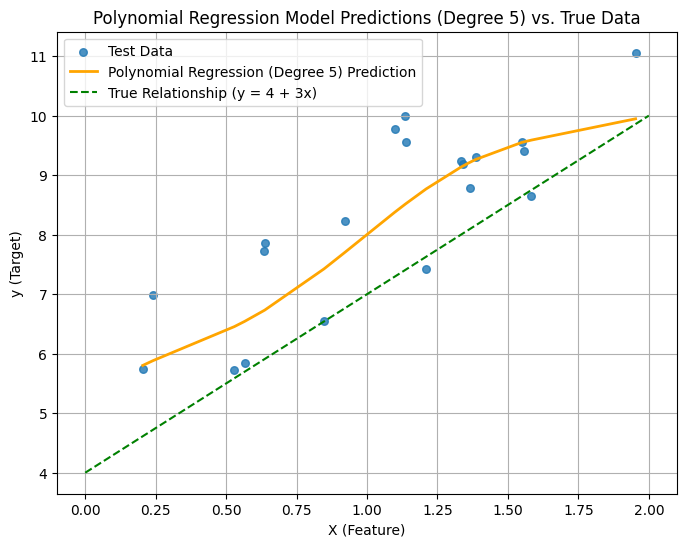

In [100]:
plt.figure(figsize=(8, 6))
# Plot the first feature of X_test against y_test
plt.scatter(X_test[:, 0], y_test, s=30, alpha=0.8, label='Test Data')

# To plot the polynomial curve, we need to sort the X values
# Use only the first feature for plotting the polynomial curve
X_sorted_plot = np.sort(X_test[:, 0]).reshape(-1, 1) # Sort and reshape to (n_samples, 1)
X_sorted_poly = poly_features.transform(X_sorted_plot)
y_pred_sorted_poly = model_poly.predict(X_sorted_poly)

plt.plot(X_sorted_plot, y_pred_sorted_poly, color='orange', linewidth=2, label=f'Polynomial Regression (Degree {degree}) Prediction')

# Plot the true underlying relationship (for comparison)
X_true_plot = np.linspace(0, 2, 100).reshape(-1, 1)
y_true_plot = 4 + 3 * X_true_plot
plt.plot(X_true_plot, y_true_plot, 'g--', label='True Relationship (y = 4 + 3x)')

plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title(f'Polynomial Regression Model Predictions (Degree {degree}) vs. True Data')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 1], residuals_poly, s=30, alpha=0.7) # Plotting against the second feature of X_test
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('X2 (Feature 2)')
plt.ylabel('Residuals')
plt.title('Residuals vs. X2 (Polynomial Model - Feature 2)')
plt.grid(True)
plt.show()

### 10. Incorporate X2 into Polynomial Features and Retrain

In [101]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features for both X1 and X2 (from X_multi)
degree = 2 # Let's start with a lower degree to manage complexity
poly_features_multi = PolynomialFeatures(degree=degree, include_bias=False)
X_multi_poly = poly_features_multi.fit_transform(X_multi)

# Split the new polynomial data into training and testing sets
X_train_multi_poly, X_test_multi_poly, y_train, y_test = train_test_split(X_multi_poly, y, test_size=0.2, random_state=42)

# Create a new Linear Regression model for polynomial features from X_multi
model_multi_poly = LinearRegression()

# Train the new model
model_multi_poly.fit(X_train_multi_poly, y_train)

print(f"Polynomial Features (Degree {degree}) shape: {X_multi_poly.shape}")
print(f"Polynomial Model (with X1 and X2) Coefficients: {model_multi_poly.coef_[0]}")
print(f"Polynomial Model (with X1 and X2) Intercept: {model_multi_poly.intercept_[0]:.2f}")

Polynomial Features (Degree 2) shape: (100, 5)
Polynomial Model (with X1 and X2) Coefficients: [ 3.16616462  2.83091841 -0.10682767 -0.57242633 -0.50867086]
Polynomial Model (with X1 and X2) Intercept: 3.85


### 11. Evaluate the New Polynomial Model (with X1 and X2 Features)

In [102]:
# Make predictions using the testing set with the new polynomial features
y_pred_multi_poly = model_multi_poly.predict(X_test_multi_poly)

# Evaluate the new model
mse_multi_poly = mean_squared_error(y_test, y_pred_multi_poly)
r2_multi_poly = r2_score(y_test, y_pred_multi_poly)

print(f"Polynomial Model (with X1 and X2) Mean Squared Error: {mse_multi_poly:.2f}")
print(f"Polynomial Model (with X1 and X2) R-squared: {r2_multi_poly:.2f}")

Polynomial Model (with X1 and X2) Mean Squared Error: 0.70
Polynomial Model (with X1 and X2) R-squared: 0.69


### 12. Analyze Residuals for the New Polynomial Model

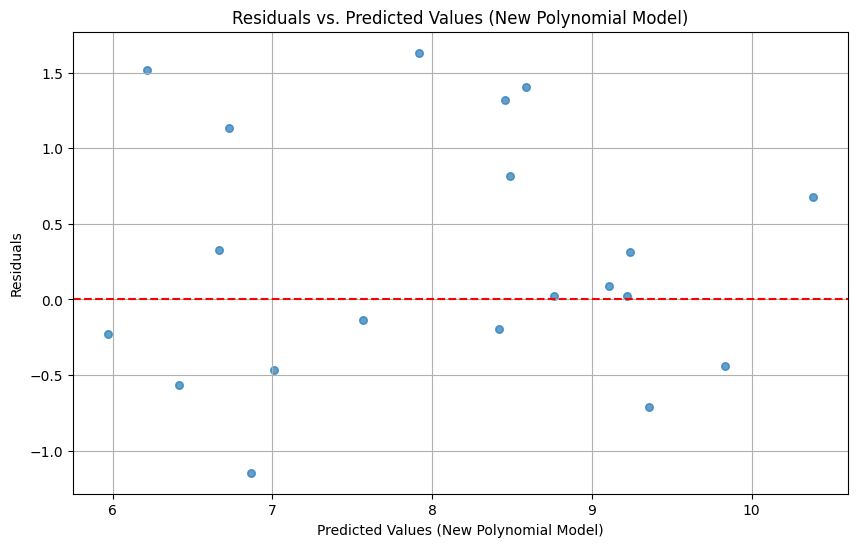

In [103]:
# Calculate residuals for the new polynomial model
residuals_multi_poly = y_test - y_pred_multi_poly

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multi_poly, residuals_multi_poly, s=30, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel('Predicted Values (New Polynomial Model)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values (New Polynomial Model)')
plt.grid(True)
plt.show()